In [1]:
import pandas as pd

df = pd.read_csv("../data/esol_descriptors.csv")
df.head()

,Compound ID,ESOL predicted log solubility in mols per litre,Minimum Degree,Molecular Weight,Number of H-Bond Donors,Number of Rings,Number of Rotatable Bonds,Polar Surface Area,measured log solubility in mols per litre,smiles,MW,LogP,TPSA,HBD,HBA,RotatableBonds
0,Amigdalin,-0.974,1,457.432,7,3,7,202.32,-0.77,OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)...,457.432,-3.10802,202.32,7,12,7
1,Fenfuram,-2.885,1,201.225,1,2,2,42.24,-3.30,Cc1occc1C(=O)Nc2ccccc2,201.225,2.84032,42.24,1,2,2
2,citral,-2.579,1,152.237,0,0,4,17.07,-2.06,CC(C)=CCCC(C)=CC(=O),152.237,2.87800,17.07,0,1,4
3,Picene,-6.618,2,278.354,0,5,0,0.00,-7.87,c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43,278.354,6.29940,0.00,0,0,0
4,Thiophene,-2.232,2,84.143,0,1,0,0.00,-1.33,c1ccsc1,84.143,1.74810,0.00,0,1,0


In [2]:
target_column = "measured log solubility in mols per litre"
feature_columns = ["MW", "LogP", "TPSA", "HBD", "HBA", "RotatableBonds"]

X = df[feature_columns]
y = df[target_column]

X.head(), y.head()

(        MW     LogP    TPSA  HBD  HBA  RotatableBonds
 0  457.432 -3.10802  202.32    7   12               7
 1  201.225  2.84032   42.24    1    2               2
 2  152.237  2.87800   17.07    0    1               4
 3  278.354  6.29940    0.00    0    0               0
 4   84.143  1.74810    0.00    0    1               0,
 0   -0.77
 1   -3.30
 2   -2.06
 3   -7.87
 4   -1.33
 Name: measured log solubility in mols per litre, dtype: float64)

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((902, 6), (226, 6), (902,), (226,))

In [4]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

y_pred_lr = lin_reg.predict(X_test)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

rmse_lr, mae_lr, r2_lr

(np.float64(1.1052101032239467), 0.8377191733991917, 0.7415823663951286)

In [5]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

rmse_rf, mae_rf, r2_rf

(np.float64(0.83256214152298), 0.5709630213944117, 0.8533555031345997)

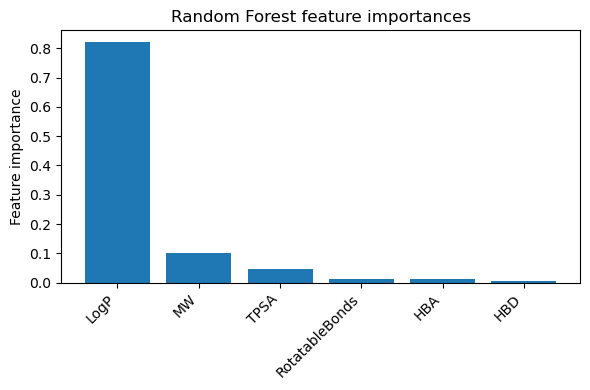

LogP: 0.8207
MW: 0.1025
TPSA: 0.0461
RotatableBonds: 0.0129
HBA: 0.0107
HBD: 0.0071


In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Get feature names and importances from the trained Random Forest
feature_names = X_train.columns if hasattr(X_train, "columns") else [f"f{i}" for i in range(X_train.shape[1])]
importances = rf.feature_importances_

# Sort features by importance (descending)
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(6, 4))
plt.bar(range(len(importances)), importances[indices], align="center", color="tab:blue")
plt.xticks(range(len(importances)), np.array(feature_names)[indices], rotation=45, ha="right")
plt.ylabel("Feature importance")
plt.title("Random Forest feature importances")
plt.tight_layout()
plt.savefig("../figures/esol_rf_feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

# Print feature name -> importance
for idx in indices:
    print(f"{feature_names[idx]}: {importances[idx]:.4f}")

In [7]:
results = pd.DataFrame(
    {
        "model": ["LinearRegression", "RandomForest"],
        "RMSE": [rmse_lr, rmse_rf],
        "MAE": [mae_lr, mae_rf],
        "R2": [r2_lr, r2_rf],
    }
)

results

,model,RMSE,MAE,R2
0,LinearRegression,1.105210,0.837719,0.741582
1,RandomForest,0.832562,0.570963,0.853356


In [8]:
results.to_csv("../results/esol_baseline_models.csv", index=False)

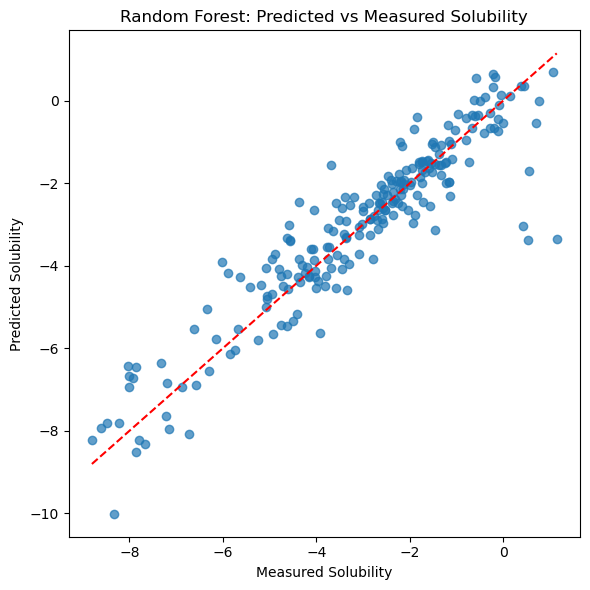

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.xlabel("Measured Solubility")
plt.ylabel("Predicted Solubility")
plt.title("Random Forest: Predicted vs Measured Solubility")
plt.tight_layout()
plt.savefig("../figures/esol_rf_pred_vs_measured.png", dpi=300, bbox_inches="tight")
plt.show()

In [10]:
results

,model,RMSE,MAE,R2
0,LinearRegression,1.105210,0.837719,0.741582
1,RandomForest,0.832562,0.570963,0.853356


In [11]:
results.to_csv("../results/esol_baseline_models.csv", index=False)